# A-SIS implementation

In [16]:
import networkx as nx
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt


## N-Intertwined SIS Model for Epidemic Spread

Van Mieghem *et al.* [15] derived a set of ordinary differential equations, called the N-intertwined model, which represents the time evolution of the probability of infection for each individual. In this model, a network of $ N $ individuals is considered where each individual is represented by a node and the contact topology is represented by a graph $ \mathcal{G} $.

A disease in this model is characterized by **infection rate** $ \beta \in \mathbb{R}^{+} $ and **curing rate** $ \delta \in \mathbb{R}^{+} $. The N-intertwined model describes the time evolution of the infection probability of the $ i $-th individual, denoted by $ p_i \in [0,1] $, as:

$$
\dot{p}_i = \beta (1 - p_i) \sum_{j \in \mathcal{N}_i} a_{ij} p_j - \delta p_i, \quad i \in \{1, \dots, N\}
$$

where $ a_{ij} > 0 $ if individual $ j $ can potentially infect individual $ i $, i.e. $ j \in \mathcal{N}_i $, otherwise $ a_{ij} = 0 $.


In [18]:
def sis_model(p, t, A, beta, delta):
    return beta * (1 - p) * (A @ p) - delta * p

Define a new state $ x_i \triangleq [s_i, p_i, q_i]^T $, where $ s_i, p_i $, and $ q_i $ denote the probabilities of individual $ i $ to be susceptible, infected, and alert, respectively. According to (5), **the time evolution of $ x_i $ can be described by the following differential equations**:

$$
\dot{x}_i = \Theta_i^T x_i, \quad i \in \{1, \ldots, N\},
$$

where

$$
\Theta_i \triangleq
\begin{bmatrix}
-\delta & 0 & \delta \\
\beta a y_i & -\beta a y_i & 0 \\
\beta y_i & \kappa y_i & -(\beta + \kappa) y_i
\end{bmatrix}
$$

is the **infinitesimal transition matrix**, and $ y_i \triangleq \sum_{j \in \mathcal{N}_i} a_{ij} p_j $.

One property of the dynamic system (6) is that $ s_i + p_i + q_i $ is a preserved quantity. Hence, **the states $ s_i, p_i $, and $ q_i $ are not independent**.

Omitting $ s_i $ in (6), the SAIS spreading model is obtained as:

$$
\dot{p}_i = \beta (1 - p_i - q_i) \sum_{j \in \mathcal{N}_i} a_{ij} p_j + \beta a q_i \sum_{j \in \mathcal{N}_i} a_{ij} p_j - \delta p_i,
$$

$$
\dot{q}_i = \kappa (1 - p_i - q_i) \sum_{j \in \mathcal{N}_i} a_{ij} p_j - \beta a q_i \sum_{j \in \mathcal{N}_i} a_{ij} p_j,
$$

for $ i \in \{1, \ldots, N\} $.


In [13]:
def sais_model(y, t, A, beta, beta_a, delta, kappa):
    N = A.shape[0]
    p = y[:N]
    q = y[N:]
    dpdt = np.zeros(N)
    dqdt = np.zeros(N)

    for i in range(N):
        yi = sum(A[i, j] * p[j] for j in range(N))
        dpdt[i] = beta * (1 - p[i] - q[i]) * yi + beta_a * q[i] * yi - delta * p[i]
        dqdt[i] = kappa * (1 - p[i] - q[i]) * yi - beta_a * q[i] * yi
    return np.concatenate([dpdt, dqdt])

In [14]:
def simulate_sais(A, beta, beta_a, delta, kappa, p0_init, t):
    N = A.shape[0]
    q0 = np.zeros(N)
    y0 = np.concatenate([p0_init, q0])
    sol = odeint(sais_model, y0, t, args=(A, beta, beta_a, delta, kappa))
    p_sol = sol[:, :N]
    return p_sol.mean(axis=1)

![fig2](fig2.png)

In order to examine the analytical results developed for the SAIS spreading model, three examples are provided in this section. In all of the simulations, **the curing rate is fixed at** $ \delta = 1 $ **so that the dimensionless time** $ \bar{t} = \delta t $ **is the same as the simulat**

**We consider an arbitrary contact graph with 11 nodes and 16 links.** For this network, the **spectral radius is found to be** $ \rho(A) = 3.1385 $. For the simulation purpose, **three nodes are initialized in the infected state while others are all susceptible.**

In **Fig. 2**, three trajectories of the total infection fraction $ \bar{p}(t) = \frac{1}{N} \sum_{i=1}^{N} p_i(t) $ are plotted. For all the three, $ \kappa = 0.1 $ and $ \beta_a = 0.1 $. The trajectories (a) and (b) correspond to the N-intertwined SIS model (1) and the SAIS spreading model (8) and (9), respectively, with $ \beta = 2 $. **Trajectory (c) is the solution of the SIS model with the infection rate $ \beta_{\text{eff}} $ defined in (26).**

As is expected from Theorem 1, the infected fraction in SIS model always dominates the SAIS model. In addition, as proved in Theorem 4, the steady state infection fraction in the SAIS is equal to that of the SIS model with the effective infection rate $ \beta_{\text{eff}} $. In **Fig. 2**, it can be observed that **the infection probabilities in the SAIS model spread similar to the SIS model at the first stage. Then, the size of the epidemics is reduced due to increased alertness in the network.**


In [15]:
N = 11 # 11 nodes
A = np.zeros((N, N))
edges = [(0, 1), (0, 4), (0, 5), (1, 2), (2, 3), (2, 6), (3, 4), (4, 7),
         (5, 8), (6, 9), (7, 10), (8, 9), (9, 10), (1, 9), (3, 8), (5, 7)] # 16 links

for i, j in edges:
    A[i, j] = A[j, i] = 1

beta, beta_a, delta, kappa = 2, 0.1, 1, 0.1
p0 = np.zeros(N)
p0[[0, 5, 10]] = 1
t = np.linspace(0, 25, 200)

p_sais = simulate_sais(A, beta, beta_a, delta, kappa, p0, t)

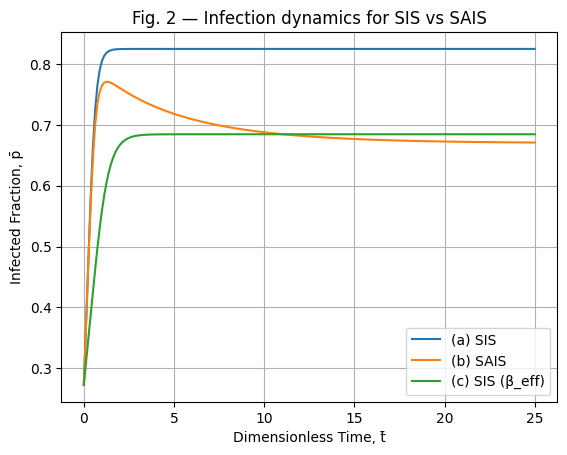

In [20]:
sis_sol = odeint(sis_model, p0, t, args=(A, beta, delta))
p_sis = sis_sol.mean(axis=1)

#beta_eff = beta * (beta_a * kappa / (kappa + beta_a) + beta_a / (kappa + beta_a))
beta_eff = beta * (beta_a / (kappa + beta_a) + (beta_a * kappa) / (kappa + beta_a))
sis_eff_sol = odeint(sis_model, p0, t, args=(A, beta_eff, delta))
p_sis_eff = sis_eff_sol.mean(axis=1)

plt.figure()
plt.plot(t, p_sis, label='(a) SIS')
plt.plot(t, p_sais, label='(b) SAIS')
plt.plot(t, p_sis_eff, label='(c) SIS (β_eff)')
plt.xlabel('Dimensionless Time, t̄')
plt.ylabel('Infected Fraction, p̄')
plt.legend()
plt.title('Fig. 2 — Infection dynamics for SIS vs SAIS')
plt.grid()
plt.show()

*Example 2:* In this example, for the same network in the previous example, (1) **the steady state value of the infected fraction** and (2) **the maximum value of the infected fraction** are plotted as a function of the infection strength $ \tau = \beta / \delta $. The simulation parameters are chosen as $ \kappa = 1 $, $ \beta_a = 0.1 $.


![fig3](fig3.png)

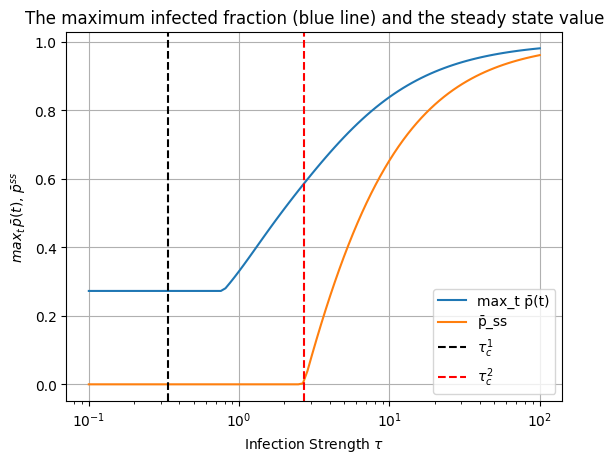

In [41]:
tau_vals = np.logspace(-1, 2, 100)
max_p, ss_p = [], []
kappa = 1
beta_a = 0.1
t = np.linspace(0,500, 400)

for tau in tau_vals:
    beta = tau * delta
    p_sol = simulate_sais(A, beta, beta_a, delta, kappa, p0, t)
    max_p.append(max(p_sol))
    ss_p.append(p_sol[-1])

plt.figure()
plt.plot(tau_vals, max_p, label='max_t p̄(t)')
plt.plot(tau_vals, ss_p, label='p̄_ss')
plt.axvline(x=1 / max(np.linalg.eigvals(A)), color='k', linestyle='--', label=rf'$\tau_c^1$')
tau2 = 1 / max(np.linalg.eigvals(A)) + kappa / beta_a * (1 / max(np.linalg.eigvals(A)) - beta_a / delta)
plt.axvline(x=tau2, color='r', linestyle='--', label=rf'$\tau_c^2$')
plt.xscale('log')
plt.xlabel(rf'Infection Strength $\tau$')
plt.ylabel(r'$max_t\,\bar{p}(t)$, $\bar{p}^{ss}$')
plt.legend()
plt.title('The maximum infected fraction (blue line) and the steady state value')
plt.grid()
plt.show()
